# H2O AutoML — Explainability (모델 설명 가능성)

> `h2o.explain()` 한 줄로 다중 모델 비교 + 리더 모델 해석 시각화

---

**사전 조건**: `01_h2o_automl_demo.ipynb`에서 AutoML 학습이 완료된 상태여야 합니다.

같은 H2O 클러스터 세션에서 이어서 실행하거나, 아래에서 클러스터에 재연결합니다.

In [1]:
import h2o
from h2o.automl import H2OAutoML

# 기존 클러스터에 연결 (이미 실행 중이면 재사용)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment Homebrew (build 17.0.18+0); OpenJDK 64-Bit Server VM Homebrew (build 17.0.18+0, mixed mode, sharing)
  Starting server from /Users/harrisonkim/Documents/project/H2O_AutoML/.venv/lib/python3.9/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/n8/4qyw51dd5cz_tjkpxs_r5fjh0000gn/T/tmpdsh0clbq
  JVM stdout: /var/folders/n8/4qyw51dd5cz_tjkpxs_r5fjh0000gn/T/tmpdsh0clbq/h2o_harrisonkim_started_from_python.out
  JVM stderr: /var/folders/n8/4qyw51dd5cz_tjkpxs_r5fjh0000gn/T/tmpdsh0clbq/h2o_harrisonkim_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Asia/Seoul
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,8 days
H2O_cluster_name:,H2O_from_python_harrisonkim_0tqbgb
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [2]:
# 기존 AutoML 프로젝트 재사용 시도, 없으면 새로 학습
try:
    aml = h2o.automl.get_automl("credits_automl")
    credits = h2o.import_file("../datasets/credit_card_transactions.csv")
    y = "is_fraud"
    credits[y] = credits[y].asfactor()
    train, test = credits.split_frame(ratios=[0.8], seed=42)
    print(f"기존 모델 재사용: {aml.leaderboard.nrows}개 모델")
except Exception:
    # 새 세션인 경우: 데이터 로드 + AutoML 재학습 (2분)
    credits = h2o.import_file("../datasets/credit_card_transactions.csv")
    y = "is_fraud"
    credits[y] = credits[y].asfactor()
    train, test = credits.split_frame(ratios=[0.8], seed=42)

    drop_cols = ["Unnamed: 0", "trans_num"]
    x = [c for c in credits.columns if c != y and c not in drop_cols]

    aml = H2OAutoML(max_runtime_secs=120, seed=42, project_name="credits_explain")
    aml.train(x=x, y=y, training_frame=train)
    print(f"학습 완료: {aml.leaderboard.nrows}개 모델")

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
00:37:23.835: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
학습 완료: 16개 모델


---
## 1. h2o.explain() — 원클릭 모델 설명

AutoML 객체를 넘기면 **다중 모델 비교**와 **리더 모델 상세 분석**을 한꺼번에 생성합니다.

생성되는 시각화:
- **Leaderboard** (모델 성능 비교표)
- **Variable Importance** (변수 중요도 히트맵)
- **Model Correlation** (모델 간 예측 상관관계)
- **Partial Dependence Plots** (부분 의존도)
- **SHAP Summary** (리더 모델)

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
StackedEnsemble_BestOfFamily_1_AutoML_1_20260321_03723,0.968631,0.0131493,0.694452,0.174036,0.0521134,0.00271581,3412,0.003593,StackedEnsemble
GBM_1_AutoML_1_20260321_03723,0.967816,0.0165802,0.692914,0.183511,0.0545606,0.00297686,14988,0.00356,GBM
StackedEnsemble_AllModels_1_AutoML_1_20260321_03723,0.961871,0.011951,0.735179,0.183656,0.0497085,0.00247093,5275,0.011164,StackedEnsemble
StackedEnsemble_BestOfFamily_2_AutoML_1_20260321_03723,0.959834,0.0121658,0.723177,0.159672,0.0503285,0.00253296,3369,0.005846,StackedEnsemble
StackedEnsemble_AllModels_2_AutoML_1_20260321_03723,0.959384,0.0116337,0.747623,0.157781,0.0487214,0.00237378,4776,0.01623,StackedEnsemble
StackedEnsemble_BestOfFamily_3_AutoML_1_20260321_03723,0.957881,0.0117546,0.73924,0.156762,0.0488747,0.00238874,4350,0.009874,StackedEnsemble
GBM_4_AutoML_1_20260321_03723,0.955112,0.0205415,0.612395,0.21643,0.0574061,0.00329546,7465,0.002375,GBM
DRF_1_AutoML_1_20260321_03723,0.950411,0.0148721,0.704779,0.173963,0.0527712,0.0027848,10854,0.002579,DRF
GBM_5_AutoML_1_20260321_03723,0.944428,0.0199245,0.584388,0.214824,0.0560371,0.00314016,4129,0.001924,GBM
GBM_2_AutoML_1_20260321_03723,0.917195,0.0218415,0.577827,0.199494,0.0555339,0.00308401,5013,0.001899,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## StackedEnsemble_BestOfFamily_1_AutoML_1_20260321_03723

,0,1,Error,Rate
0,257387.0,386.0,0.0015,(386.0/257773.0)
1,506.0,954.0,0.3466,(506.0/1460.0)
Total,257893.0,1340.0,0.0034,(892.0/259233.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

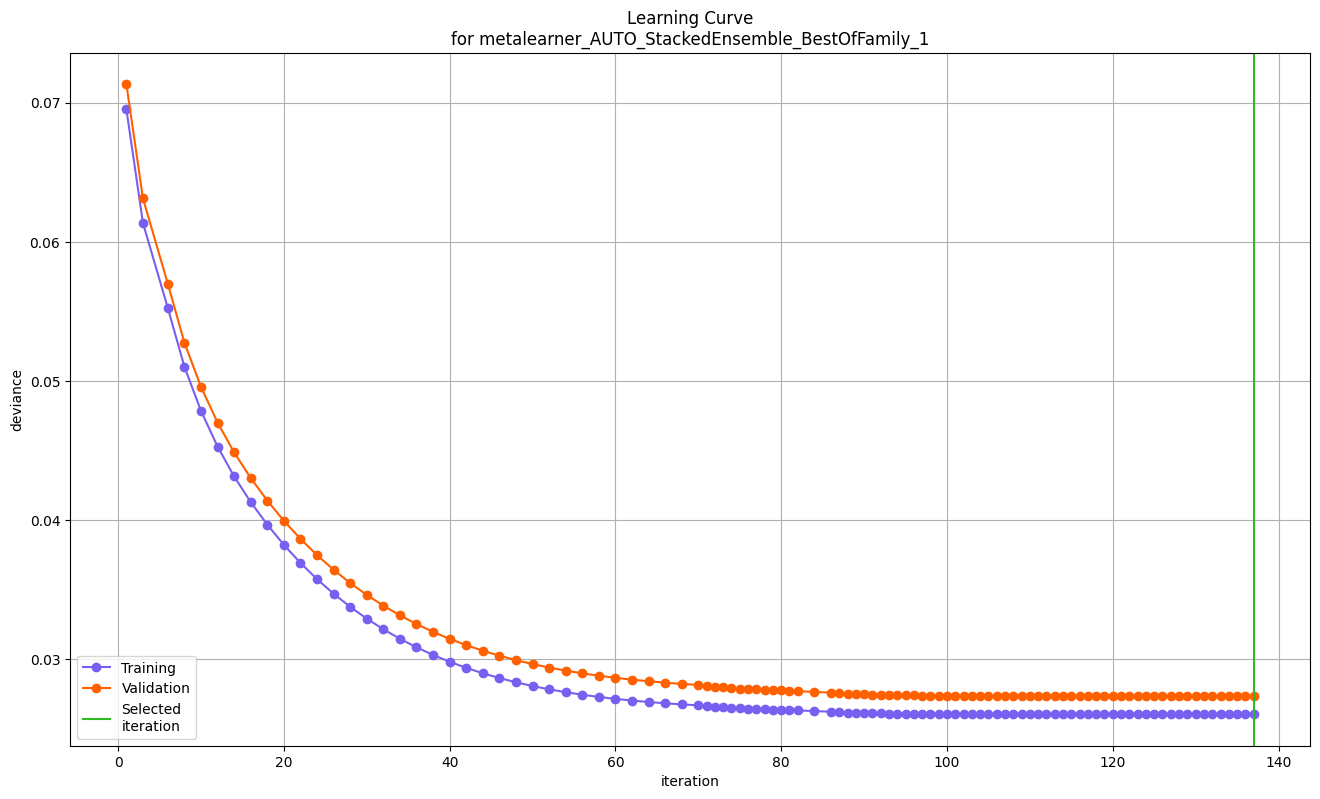

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

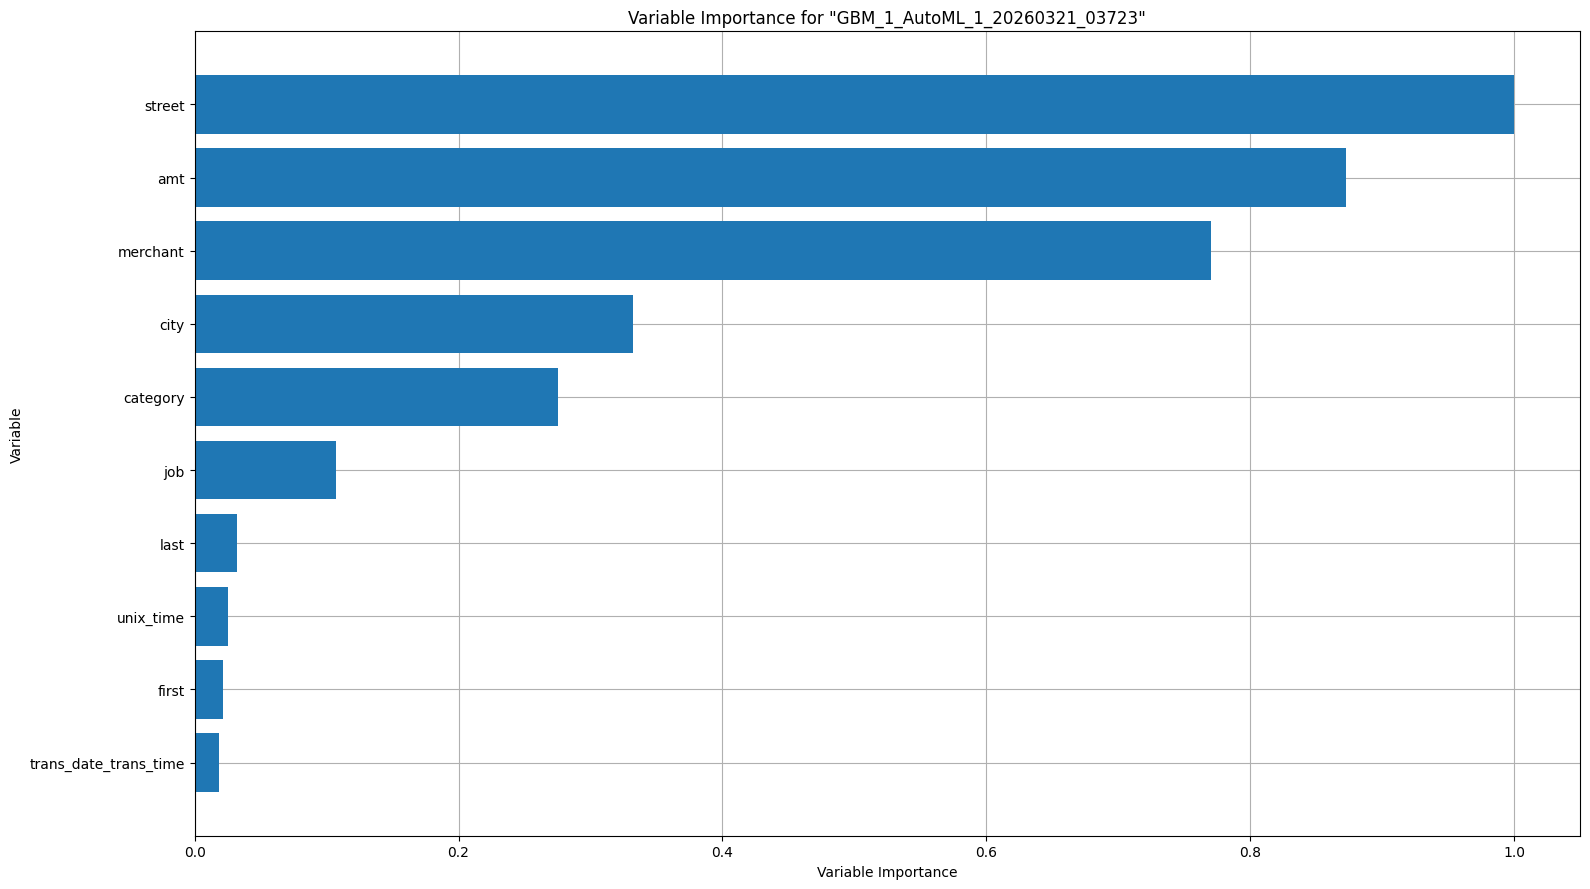

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

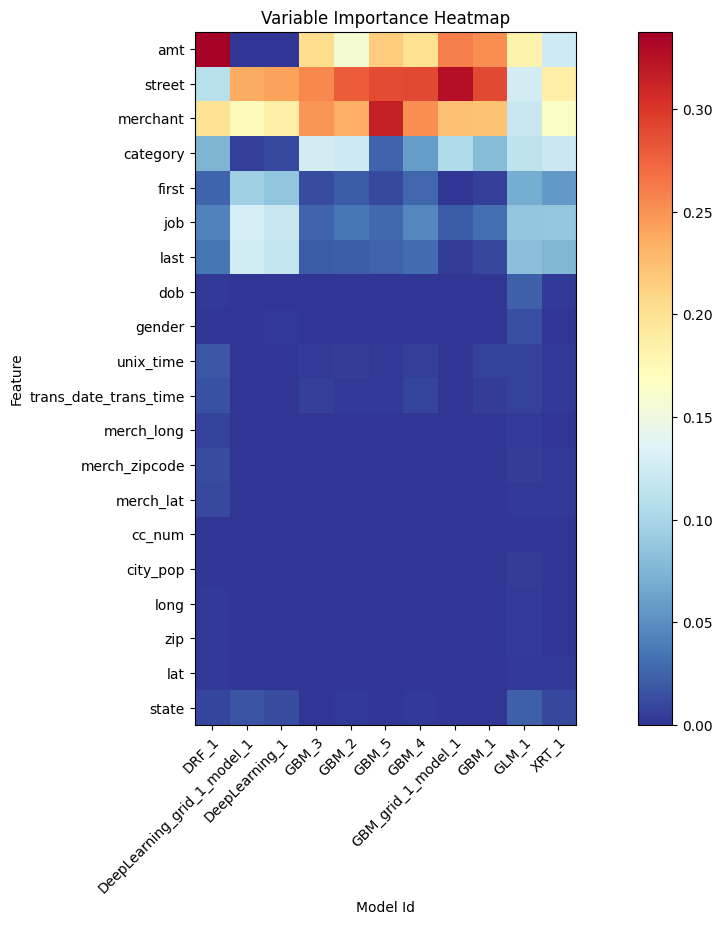

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

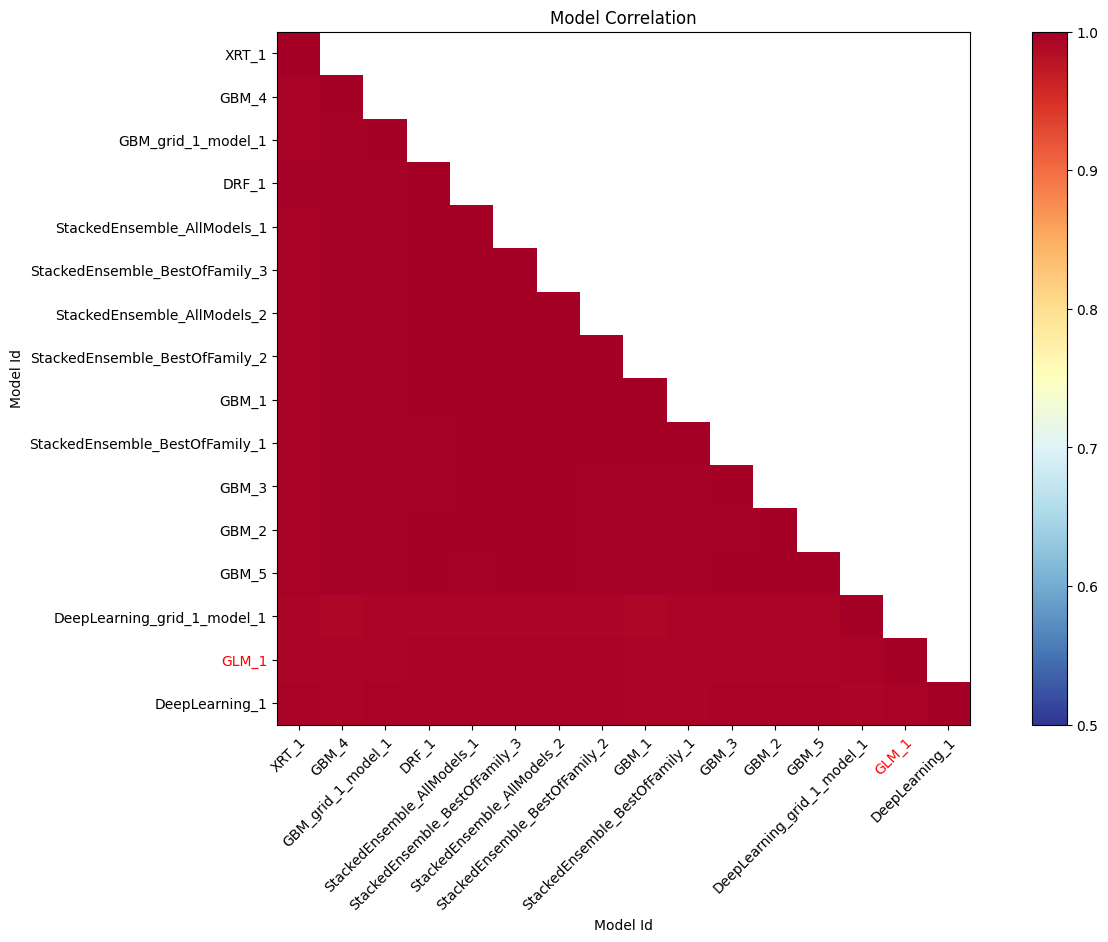

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

H2OResponseError: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_307_sid_8d58 (levels (tmp= py_306_sid_8d58 (as.factor (cols_py py_305_sid_8d58 np.str_('merchant'))))))", 'session_id': '_sid_8d58'}


In [3]:
# 한 줄로 모든 설명 시각화 생성
explanations = aml.explain(test)

---
## 2. 개별 시각화

필요한 시각화만 선택적으로 생성할 수도 있습니다.

### 2-1. 변수 중요도 히트맵

여러 모델에 걸쳐 어떤 변수가 공통적으로 중요한지 한눈에 파악합니다.

In [ ]:
# 변수 중요도 히트맵 (다중 모델 비교)
aml.varimp_heatmap()

### 2-2. 모델 간 상관관계

모델들의 예측이 얼마나 유사한지 보여줍니다. 상관이 낮은 모델들을 앙상블하면 성능이 더 올라갑니다.

In [ ]:
# 모델 상관관계 히트맵
aml.model_correlation_heatmap(test)

### 2-3. 리더 모델 상세 설명

In [ ]:
# 리더 모델만 단독 설명
leader = aml.leader
leader.explain(test)

---
## 3. 특정 모델 비교

In [ ]:
# 특정 알고리즘별 best model 비교
try:
    gbm = aml.get_best_model(algorithm="gbm")
    xgb = aml.get_best_model(algorithm="xgboost")
    
    # Partial Dependence Plot 비교
    gbm.pd_plot(test, column=train.columns[0])
    xgb.pd_plot(test, column=train.columns[0])
except Exception as e:
    print(f"일부 알고리즘이 학습되지 않았을 수 있습니다: {e}")

---
## 정리

H2O Explainability가 제공하는 것:

| 시각화 | 대상 | 용도 |
|--------|------|------|
| Leaderboard | 다중 모델 | 성능 순위 비교 |
| Variable Importance Heatmap | 다중 모델 | 공통 중요 변수 식별 |
| Model Correlation | 다중 모델 | 앙상블 다양성 확인 |
| Partial Dependence | 단일/다중 | 변수-예측 관계 시각화 |
| SHAP Summary | 단일 모델 | 개별 예측에 대한 변수 기여도 |

> **"모델을 자동으로 학습할 뿐 아니라, 왜 그런 예측을 하는지도 자동으로 설명"**
> — 이것이 H2O AutoML의 Explainability입니다.

In [ ]:
# h2o.cluster().shutdown()